# Week 2 - Preprocessing, part 2

# 1. Lesson: None

DATASET 1

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

For the SUPPORT2 dataset, the Who would be clinicians, hospital leadership, and public health researchers who are interested in outcomes for seriously ill patients. The What would be to understand which clinical and demographic factors are related to survival, length of stay, or serious illness outcomes. This could include age, sex, disease category, vital signs, lab results, and functional health measures. The How would be to present the results with simple visuals, such as bar charts, scatterplots, and grouped comparisons, to show which factors are most connected to patient outcomes. The story would focus on helping the audience understand which conditions or patient characteristics are linked to higher risk.

# 3. Homework - work with your own data

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [16]:
pip install ucimlrepo

In [17]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# Load SUPPORT2 dataset
support2_data = fetch_ucirepo(id=880)

# Convert to DataFrame
support2 = support2_data.data.original

# Preview the dataset
support2.head()

,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [18]:
print("SUPPORT2 shape:", support2.shape)
print("Number of rows:", support2.shape[0])
print("Number of columns:", support2.shape[1])

SUPPORT2 shape: (9105, 48)
Number of rows: 9105
Number of columns: 48


In [19]:
support2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   object 
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   object 
 8   dzclass   9105 non-null   object 
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   object 
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   object 
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   float64
 20  surv2m    9104 non-null   floa

In [20]:
support2.describe(include="all")

,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
count,9105.000000,9105.000000,9105.000000,9105,9105.000000,9105.000000,9105.000000,9105,9105,9105.000000,...,9038.000000,9104.000000,6821.000000,4605.000000,4753.000000,4243.000000,3464.000000,6238.000000,7705,9105.000000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,8,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,male,NaN,NaN,NaN,ARF/MOSF w/Sepsis,ARF/MOSF,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<2 mo. follow-up,NaN
freq,NaN,NaN,NaN,5125,NaN,NaN,NaN,3515,4227,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3123,NaN
mean,4553.000000,62.650823,0.681054,NaN,0.259198,17.863042,478.449863,NaN,NaN,1.868644,...,1.770961,137.568541,7.415364,159.873398,32.349463,2191.546047,1.157910,1.637384,NaN,1.888272
std,2628.531434,15.593710,0.466094,NaN,0.438219,22.006440,560.383272,NaN,NaN,1.344409,...,1.686041,6.029326,0.080563,88.391541,26.792288,1455.245777,1.739672,2.231358,NaN,2.003763
min,1.000000,18.041990,0.000000,NaN,0.000000,3.000000,3.000000,NaN,NaN,0.000000,...,0.099991,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,2277.000000,52.797000,0.000000,NaN,0.000000,6.000000,26.000000,NaN,NaN,1.000000,...,0.899902,134.000000,7.379883,103.000000,14.000000,1165.500000,0.000000,0.000000,NaN,0.000000
50%,4553.000000,64.856990,1.000000,NaN,0.000000,11.000000,233.000000,NaN,NaN,2.000000,...,1.199951,137.000000,7.419922,135.000000,23.000000,1968.000000,0.000000,1.000000,NaN,1.000000
75%,6829.000000,73.998960,1.000000,NaN,1.000000,20.000000,761.000000,NaN,NaN,3.000000,...,1.899902,141.000000,7.469727,188.000000,42.000000,3000.000000,2.000000,3.000000,NaN,3.000000


For SUPPORT2, duplicate values are normal in columns like age, sex, race, and disease group because many patients can share the same values.

But if there is an ID column, duplicate values would be inappropriate:

In [29]:
# Run this only if there is an ID column
if "id" in support2.columns:
    print("Duplicate IDs:", support2["id"].duplicated().sum())
else:
    print("No ID column named 'id' found.")

Duplicate IDs: 0


In [30]:
#unique values for important columns:
for col in ["age", "sex", "race", "dzgroup"]:
    if col in support2.columns:
        print("\nColumn:", col)
        print(support2[col].value_counts(dropna=False))


Column: age
age
71.99695    5
55.42499    4
56.00299    4
59.31000    4
55.13797    4
           ..
49.11697    1
70.36798    1
63.43298    1
76.72797    1
53.32498    1
Name: count, Length: 7323, dtype: int64

Column: sex
sex
male      5125
female    3980
Name: count, dtype: int64

Column: race
race
white       7191
black       1391
hispanic     290
other        112
asian         79
NaN           42
Name: count, dtype: int64

Column: dzgroup
dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64


In [33]:
numeric_cols = support2.select_dtypes(include=["int64", "float64"])

mean_values = numeric_cols.mean()
median_values = numeric_cols.median()
mode_values = support2.mode().iloc[0]

print("Mean values:")
print(mean_values)

print("\nMedian values:")
print(median_values)

print("\nMode values:")
print(mode_values)

Mean values:
id           4553.000000
age            62.650823
death           0.681054
hospdead        0.259198
slos           17.863042
d.time        478.449863
num.co          1.868644
edu            11.747691
scoma          12.058546
charges     59995.787811
totcst      30825.867768
totmcst     28828.877838
avtisst        22.610928
sps            25.525872
aps            37.597979
surv2m          0.635870
surv6m          0.520096
hday            4.400000
diabetes        0.195277
dementia        0.032510
prg2m           0.618769
prg6m           0.499679
dnrday         14.582590
meanbp         84.546408
wblc           12.347677
hrt            97.156711
resp           23.330294
temp           37.103341
pafi          239.529070
alb             2.950520
bili            2.554463
crea            1.770961
sod           137.568541
ph              7.415364
glucose       159.873398
bun            32.349463
urine        2191.546047
adlp            1.157910
adls            1.637384
adlsc       

In [34]:
missing_count = support2.isnull().sum()
missing_percent = (support2.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})

missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percent
edu,1634,17.95
income,2982,32.75
scoma,1,0.01
charges,172,1.89
totcst,888,9.75
totmcst,3475,38.17
avtisst,82,0.90
race,42,0.46
sps,1,0.01
aps,1,0.01


In [35]:
print("Total missing values:", support2.isnull().sum().sum())

Total missing values: 47110


For SUPPORT2, I would usually use:

Median for numeric columns because healthcare data can have outliers.
“Unknown” for categorical columns.
Remove a row only if it is missing important outcome information.

In [36]:
support2_clean = support2.copy()

# Fill categorical missing values with "Unknown"
categorical_cols = support2_clean.select_dtypes(include=["object"]).columns
support2_clean[categorical_cols] = support2_clean[categorical_cols].fillna("Unknown")

# Fill numeric missing values with median
numeric_cols = support2_clean.select_dtypes(include=["int64", "float64"]).columns
support2_clean[numeric_cols] = support2_clean[numeric_cols].fillna(
    support2_clean[numeric_cols].median()
)

# Check missing values after cleaning
print("Missing values after cleaning:", support2_clean.isnull().sum().sum())

Missing values after cleaning: 0


For the SUPPORT2 dataset, I filled numeric missing values with the median because medical data can contain outliers. I filled categorical missing values with “Unknown” so those records can still be included in the analysis. I would only remove rows if they were missing an important outcome variable.

Identify other inconsistent data

In [37]:
if "age" in support2_clean.columns:
    print(support2_clean["age"].describe())
    print("Negative ages:", support2_clean[support2_clean["age"] < 0].shape[0])

count    9105.000000
mean       62.650823
std        15.593710
min        18.041990
25%        52.797000
50%        64.856990
75%        73.998960
max       101.847960
Name: age, dtype: float64
Negative ages: 0


In [38]:
if "sex" in support2_clean.columns:
    print(support2_clean["sex"].value_counts(dropna=False))

sex
male      5125
female    3980
Name: count, dtype: int64


In [39]:
if "dzgroup" in support2_clean.columns:
    print(support2_clean["dzgroup"].value_counts(dropna=False))

dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64


In [40]:
support2_clean.describe()

,id,age,death,hospdead,slos,d.time,num.co,edu,scoma,charges,...,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc
count,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9.105000e+03,...,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000
mean,4553.000000,62.650823,0.681054,0.259198,17.863042,478.449863,1.868644,11.792971,12.057221,5.933515e+04,...,2.081809,1.766759,137.568479,7.416507,147.580121,27.880615,2072.174176,0.440527,1.436683,1.888272
std,2628.531434,15.593710,0.466094,0.438219,22.006440,560.383272,1.344409,3.124552,24.635665,1.017859e+05,...,4.556681,1.680534,6.028997,0.069757,64.076724,19.912206,999.597851,1.211310,1.870469,2.003763
min,1.000000,18.041990,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,1.169000e+03,...,0.099991,0.099991,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2277.000000,52.797000,0.000000,0.000000,6.000000,26.000000,1.000000,11.000000,0.000000,9.941000e+03,...,0.599976,0.899902,134.000000,7.399414,133.000000,22.000000,1968.000000,0.000000,0.000000,0.000000
50%,4553.000000,64.856990,1.000000,0.000000,11.000000,233.000000,2.000000,12.000000,0.000000,2.502400e+04,...,0.899902,1.199951,137.000000,7.419922,135.000000,23.000000,1968.000000,0.000000,1.000000,1.000000
75%,6829.000000,73.998960,1.000000,1.000000,20.000000,761.000000,3.000000,12.000000,9.000000,6.353100e+04,...,1.299805,1.899902,141.000000,7.449219,136.000000,24.000000,1968.000000,0.000000,1.000000,3.000000
max,9105.000000,101.847960,1.000000,1.000000,343.000000,2029.000000,9.000000,31.000000,100.000000,1.435423e+06,...,63.000000,21.500000,181.000000,7.769531,1092.000000,300.000000,9000.000000,7.000000,7.000000,7.073242


Encode categorial vcariables

In [41]:
support2_encoded = pd.get_dummies(support2_clean, drop_first=True)

print("Original dataset shape:", support2.shape)
print("Cleaned dataset shape:", support2_clean.shape)
print("Encoded dataset shape:", support2_encoded.shape)

Original dataset shape: (9105, 48)
Cleaned dataset shape: (9105, 48)
Encoded dataset shape: (9105, 70)


In [42]:
support2_encoded.head()

,id,age,death,hospdead,slos,d.time,num.co,edu,scoma,charges,...,ca_no,ca_yes,dnr_dnr after sadm,dnr_dnr before sadm,dnr_no dnr,sfdm2_Coma or Intub,sfdm2_SIP>=30,sfdm2_Unknown,sfdm2_adl>=4 (>=5 if sur),sfdm2_no(M2 and SIP pres)
0,1,62.84998,0,0,5,2029,0,11.0,0.0,9715.0,...,False,False,False,False,True,False,False,True,False,False
1,2,60.33899,1,1,4,4,2,12.0,44.0,34496.0,...,True,False,False,False,False,False,False,False,False,False
2,3,52.74698,1,0,17,47,2,12.0,0.0,41094.0,...,True,False,False,False,True,False,False,False,False,False
3,4,42.38498,1,0,3,133,2,11.0,0.0,3075.0,...,False,False,False,False,True,False,False,False,False,True
4,5,79.88495,0,0,16,2029,1,12.0,26.0,50127.0,...,True,False,False,False,True,False,False,False,False,True


I used one-hot encoding to convert categorical variables into numeric variables. This is needed because many machine learning models cannot use text categories directly. After encoding, the dataset has more columns because each category becomes its own numeric column.

Conclusiom

The SUPPORT2 dataset is usable for analysis. It contains many useful variables related to patient demographics, disease categories, clinical measurements, lab values, and patient outcomes. After reviewing the dataset with info() and describe(), checking duplicates, reviewing missing values, and encoding categorical variables, the dataset appears appropriate for healthcare analysis.

Yes, the SUPPORT2 dataset needs some modification before analysis. Missing numeric values should be filled with the median because healthcare data can contain outliers. Missing categorical values should be filled with “Unknown” so the rows can still be used. Categorical variables also need to be encoded using one-hot encoding because machine learning models usually require numeric values. I would also review any unusual values before final analysis.

For the SUPPORT2 dataset, class imbalance was checked using the target column death. This column shows whether a patient survived or died. If one category has many more records than the other, then the dataset has class imbalance. This is important because an imbalanced target variable can affect future modeling by causing the model to favor the larger class more often than the smaller class.

In [43]:
support2_clean.columns

Index(['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday',
       'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday',
       'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea',
       'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')

In [44]:
support2_clean["death"].value_counts()

,count
death,
1,6201
0,2904


In [45]:
support2_clean["death"].value_counts(normalize=True) * 100

,proportion
death,
1,68.105437
0,31.894563


In [46]:
support2_clean["hospdead"].value_counts()

,count
hospdead,
0,6745
1,2360


In [47]:
support2_clean["hospdead"].value_counts(normalize=True) * 100

,proportion
hospdead,
0,74.080176
1,25.919824


In [48]:
outcome_col = "death"   # change to "hospdead" if needed

class_counts = support2_clean[outcome_col].value_counts()
class_percent = support2_clean[outcome_col].value_counts(normalize=True) * 100

class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percent": class_percent.round(2)
})

class_balance

,Count,Percent
death,,
1,6201,68.11
0,2904,31.89


# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

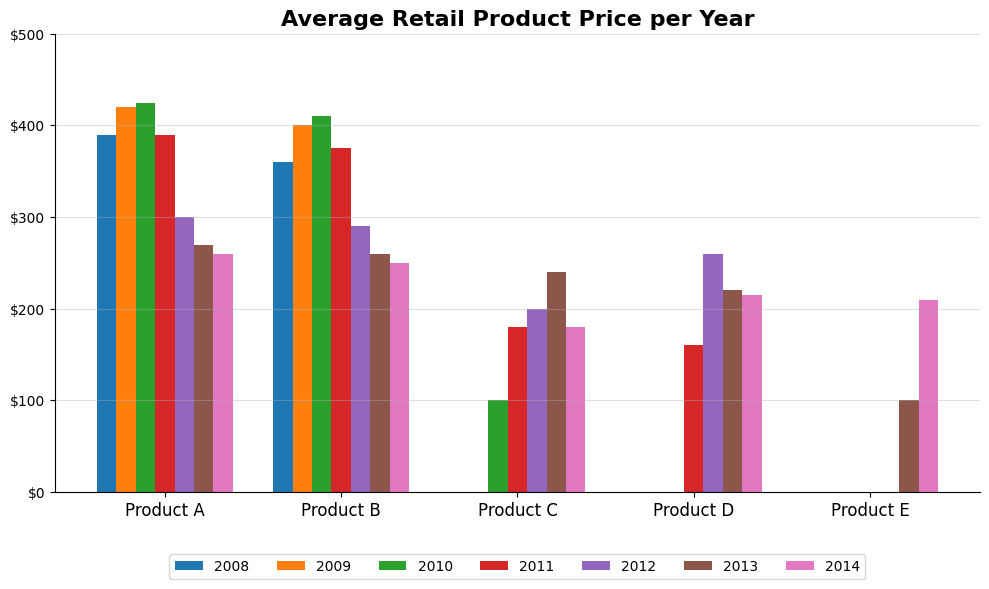

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data
products = ["Product A", "Product B", "Product C", "Product D", "Product E"]
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014]

prices = {
    2008: [390, 360, 0,   0,   0],
    2009: [420, 400, 0,   0,   0],
    2010: [425, 410, 100, 0,   0],
    2011: [390, 375, 180, 160, 0],
    2012: [300, 290, 200, 260, 0],
    2013: [270, 260, 240, 220, 100],
    2014: [260, 250, 180, 215, 210]
}

# Setup
x = np.arange(len(products))
width = 0.11

plt.figure(figsize=(10, 6))

# Create bars
for i, year in enumerate(years):
    plt.bar(
        x + (i - 3) * width,
        prices[year],
        width,
        label=str(year)
    )

# Labels and title
plt.title("Average Retail Product Price per Year", fontsize=16, fontweight="bold")
plt.xticks(x, products, fontsize=12)
plt.yticks(np.arange(0, 501, 100), [f"${i}" for i in range(0, 501, 100)])
plt.ylim(0, 500)

# Grid and legend
plt.grid(axis="y", alpha=0.4)
plt.legend(ncol=7, loc="upper center", bbox_to_anchor=(0.5, -0.12))

# Remove top and right border
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

DATASET 2

In [3]:
pip install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# metadata
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata)

# variable information
print(diabetes_130_us_hospitals_for_years_1999_2008.variables)


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

WEEKLY GRAPH QUESTION DATASET 2

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

For the Diabetes 130-US Hospitals dataset, the Who would be hospital administrators, care managers, and healthcare analysts who want to reduce patient readmissions. The What would be to identify which patient, treatment, and hospital visit factors are connected to whether a diabetic patient is readmitted after discharge. This could include age, number of medications, time in hospital, number of lab procedures, diagnosis type, and previous visits. The How would be to use clear charts and comparisons to show patterns between these factors and readmission outcomes. The story would focus on helping healthcare decision-makers understand which patients may need more follow up care after leaving the hospital.

3. Homework - work with your own data


In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do Use Google, documentation, and ChatGPT to help you:
Summarize the datasets using info() and describe()

Are there any duplicate rows?

Are there any duplicate values in a given column (when this would be inappropriate?)

What are the mean, median, and mode of each column?

Are there any missing or null values?

Do you want to fill in the missing value with a mean value? A value of your choice? Remove that row?
Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

Encode any categorical variables (e.g. with one-hot encoding.)

Conclusions:
Are the data usable? If not, find some new data!

Do you need to modify or correct the data in some way?

Is there any class imbalance? (Categories that have many more items than other categories).

In [61]:
# If needed, install this first:
# pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

In [62]:
# Load Diabetes 130-US Hospitals dataset
diabetes_data = fetch_ucirepo(id=296)

# Convert to DataFrame
diabetes = diabetes_data.data.original

# Preview the dataset
diabetes.head()

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [52]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [53]:
diabetes.describe(include="all")

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,1.017660e+05,1.017660e+05,99493,101766,101766,3197,101766.000000,101766.000000,101766.000000,101766.000000,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,NaN,NaN,5,3,10,9,NaN,NaN,NaN,NaN,...,1,4,4,2,2,2,2,2,2,3
top,NaN,NaN,Caucasian,Female,[70-80),[75-100),NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
freq,NaN,NaN,76099,54708,26068,1336,NaN,NaN,NaN,NaN,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,NaN,2.024006,3.715642,5.754437,4.395987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,NaN,1.445403,5.280166,4.064081,2.985108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,NaN,1.000000,1.000000,7.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,NaN,3.000000,4.000000,7.000000,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
# Shape of dataset
print("Rows and columns:", diabetes.shape)
print("Number of rows:", diabetes.shape[0])
print("Number of columns:", diabetes.shape[1])

Rows and columns: (101766, 50)
Number of rows: 101766
Number of columns: 50


In [55]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [63]:
# Check duplicate encounter IDs
diabetes["encounter_id"].duplicated().sum()

np.int64(0)

In [64]:
diabetes["patient_nbr"].duplicated().sum()

np.int64(30248)

In [65]:
numeric_cols = diabetes.select_dtypes(include=["int64", "float64"]).columns

stats = pd.DataFrame({
    "Mean": diabetes[numeric_cols].mean(),
    "Median": diabetes[numeric_cols].median(),
    "Mode": diabetes[numeric_cols].mode().iloc[0]
})

stats

,Mean,Median,Mode
encounter_id,1.652016e+08,152388987.0,12522.0
patient_nbr,5.433040e+07,45505143.0,88785891.0
admission_type_id,2.024006e+00,1.0,1.0
discharge_disposition_id,3.715642e+00,1.0,1.0
admission_source_id,5.754437e+00,7.0,7.0
time_in_hospital,4.395987e+00,4.0,3.0
num_lab_procedures,4.309564e+01,44.0,1.0
num_procedures,1.339730e+00,1.0,0.0
num_medications,1.602184e+01,15.0,13.0
number_outpatient,3.693572e-01,0.0,0.0


In [67]:
diabetes = diabetes.replace("?", np.nan)

In [68]:
diabetes.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [69]:
diabetes.isnull().sum()[diabetes.isnull().sum() > 0].sort_values(ascending=False)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


In [70]:
missing_percent = (diabetes.isnull().sum() / len(diabetes)) * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636


In [71]:
diabetes = diabetes.drop(columns=["weight"])

In [72]:
for col in ["race", "payer_code", "medical_specialty"]:
    diabetes[col] = diabetes[col].fillna("Unknown")

In [73]:
diabetes.isnull().sum()[diabetes.isnull().sum() > 0]

,0
diag_1,21
diag_2,358
diag_3,1423
max_glu_serum,96420
A1Cresult,84748


In [74]:
#Identify inconsistent data
diabetes["gender"].value_counts()

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [75]:
diabetes = diabetes[diabetes["gender"] != "Unknown/Invalid"]

In [76]:
diabetes["time_in_hospital"].describe()

,time_in_hospital
count,101763.000000
mean,4.396018
std,2.985092
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,14.000000


In [77]:
diabetes[(diabetes["time_in_hospital"] < 1) | (diabetes["time_in_hospital"] > 14)]

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


In [78]:
diabetes["age"].value_counts().sort_index()

,count
age,
[0-10),161
[10-20),691
[20-30),1657
[30-40),3775
[40-50),9685
[50-60),17256
[60-70),22482
[70-80),26066
[80-90),17197


In [79]:
#Encode categorical variables

categorical_cols = diabetes.select_dtypes(include="object").columns
categorical_cols

Index(['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1',
       'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [80]:
diabetes_encoded = pd.get_dummies(diabetes, columns=categorical_cols, drop_first=True)

In [81]:
diabetes_encoded.head()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes,readmitted_>30,readmitted_NO
0,2278392,8222157,6,25,1,1,41,0,1,0,...,False,False,False,False,False,False,True,False,False,True
1,149190,55629189,1,1,7,3,59,0,18,0,...,False,False,False,False,False,False,False,True,True,False
2,64410,86047875,1,1,7,2,11,5,13,2,...,False,False,False,False,False,False,True,True,False,True
3,500364,82442376,1,1,7,2,44,1,16,0,...,False,False,False,False,False,False,False,True,False,True
4,16680,42519267,1,1,7,1,51,0,8,0,...,False,False,False,False,False,False,False,True,False,True


In [82]:
print("Original shape:", diabetes.shape)
print("Encoded shape:", diabetes_encoded.shape)

Original shape: (101763, 49)
Encoded shape: (101763, 2423)


In [83]:
diabetes["readmitted"].value_counts()

,count
readmitted,
NO,54861
>30,35545
<30,11357


In [84]:
diabetes["readmitted"].value_counts(normalize=True) * 100

,proportion
readmitted,
NO,53.910557
>30,34.929198
<30,11.160245


<Axes: title={'center': 'Readmitted Class Distribution'}, xlabel='readmitted'>

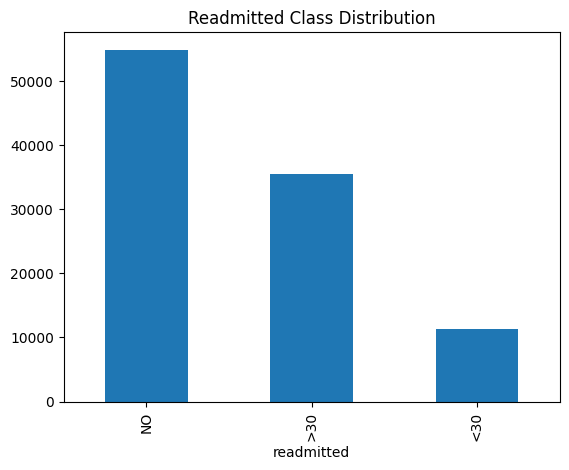

In [85]:
diabetes["readmitted"].value_counts().plot(kind="bar", title="Readmitted Class Distribution")

Conclusion

The Diabetes 130-US Hospitals dataset is usable for analysis, but it needs cleaning before further analysis or modeling. The dataset contains missing values, and some missing values are shown as "?", so those values had to be replaced with null values. The weight column had too many missing values, so it was removed. Other categorical columns, such as race, payer_code, and medical_specialty, were filled with "Unknown". I also checked for duplicate rows, duplicate encounter IDs, duplicate patient numbers, missing values, inconsistent values, and class imbalance. Overall, the dataset is usable after cleaning and encoding the categorical variables. There is some class imbalance in the readmitted column because some categories have many more records than others. This could affect future modeling because the model may learn to predict the larger categories more often than the smaller category.